# Face Recognition with FaceNet & Triplet Loss
## Lab 4 - Task 2 | Olivetti + VGGFace2 Subset | InceptionResnetV1

---

### What is Face Recognition?

Face recognition answers two questions:

| Task | Question | Real-world example |
|------|----------|--------------------|
| **Verification** (1:1) | Are these two photos the same person? | Passport control |
| **Identification** (1:N) | Who is this person? | Employee access system |

### How FaceNet Works

FaceNet maps every face photo to a vector of 512 numbers called an **embedding**.

```
Photo A (Alice) -> [0.12, -0.34, 0.87, ...]   <- 512 numbers
Photo B (Alice) -> [0.11, -0.33, 0.85, ...]   <- very close (same person)
Photo C (Bob)   -> [0.91,  0.45, -0.12, ...]  <- very different (diff person)
```

To decide if two photos are the same person: compute **Euclidean distance**.
Small distance = same person. Large distance = different people.

### Triplet Loss

```
Triplet = (Anchor A, Positive P, Negative N)
  Anchor   = face of Person X
  Positive = another face of Person X   [same identity]
  Negative = face of Person Y           [different identity]

Loss = max(0,  dist(A,P) - dist(A,N) + margin)
```

The loss pulls same-person faces closer and pushes different people apart.


## Cell 1 - Safe Installation

Run this cell first, then **Runtime -> Restart session**, then run from Cell 2.

We use `--no-deps` so pip does NOT uninstall Colab's existing torch/numpy.
This prevents the `numpy.dtype size changed` crash from previous versions.


In [1]:
import subprocess

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = (r.stdout + r.stderr).strip()
    if out:
        print(out[-300:])
    return r.returncode

print('Step 1: Installing facenet-pytorch without touching existing torch...')
run('pip install facenet-pytorch --no-deps -q')

print('Step 2: Verify...')
rc = run('python -c "from facenet_pytorch import InceptionResnetV1; print(\"OK\")"')

if rc == 0:
    print()
    print('=' * 55)
    print('  Install done!')
    print('  >>> Runtime -> Restart session <<<')
    print('  Then run all cells from Cell 2 onwards.')
    print('=' * 55)
else:
    print('Something went wrong, check output above.')


Step 1: Installing facenet-pytorch without touching existing torch...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.2 MB/s eta 0:00:00
Step 2: Verify...
Traceback (most recent call last):
  File "<string>", line 1, in <module>
NameError: name 'OK' is not defined
Something went wrong, check output above.


## Cell 2 - Imports & GPU Check

*(Run after restarting runtime)*

In [2]:
import os, random, time, warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from facenet_pytorch import InceptionResnetV1

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB


## Step 1 - Load Olivetti Faces Dataset

**Olivetti Faces** (AT&T Database of Faces):
- 400 images of **40 people** (10 photos each)
- 64x64 pixels, grayscale
- Different lighting, expressions, glasses
- Comes built into scikit-learn — downloads instantly, ~1 MB
- Perfect for a face recognition lab: clean, no download issues

**Why not LFW?** LFW from sklearn returns float32 arrays in [0,255] which
matplotlib renders as black (it expects [0.0,1.0] for floats). Olivetti
returns clean float64 in [0.0,1.0] — no display bugs possible.


In [3]:
print('Loading Olivetti Faces dataset...')
olivetti = fetch_olivetti_faces(shuffle=False, random_state=SEED)

# olivetti.images: float64 in [0.0, 1.0], shape (400, 64, 64)
# olivetti.target: int array [0-39], 10 images per person
images_raw = olivetti.images   # float64 [0.0, 1.0], shape (400, 64, 64)
labels     = olivetti.target   # shape (400,), values 0-39

print(f'Images shape : {images_raw.shape}')
print(f'dtype        : {images_raw.dtype}')
print(f'Value range  : [{images_raw.min():.3f}, {images_raw.max():.3f}]')
print(f'People       : {len(np.unique(labels))}')
print(f'Images/person: {Counter(labels).most_common(1)[0][1]}')

# Convert to RGB uint8 [0-255] for consistent processing
# Olivetti is grayscale (H,W) -> replicate to 3 channels -> (H,W,3)
def to_rgb_uint8(img_float):
    """
    Convert a float [0,1] grayscale image to uint8 RGB.
    This ensures imshow() always gets correct uint8 [0-255] input.
    """
    gray_uint8 = (img_float * 255).astype(np.uint8)  # float->uint8 correctly
    rgb        = np.stack([gray_uint8]*3, axis=-1)   # (H,W) -> (H,W,3)
    return rgb

images = np.array([to_rgb_uint8(img) for img in images_raw])  # (400,64,64,3) uint8
print(f'Converted RGB shape: {images.shape}, dtype: {images.dtype}')
print(f'Value range: [{images.min()}, {images.max()}]   <- correct uint8')


Loading Olivetti Faces dataset...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Images shape : (400, 64, 64)
dtype        : float32
Value range  : [0.000, 1.000]
People       : 40
Images/person: 10
Converted RGB shape: (400, 64, 64, 3), dtype: uint8
Value range: [0, 255]   <- correct uint8


## Step 2 - Visualise the Dataset

Each row = one person (10 photos). Notice the variation in lighting,
expression, and glasses — this is what makes face recognition hard.


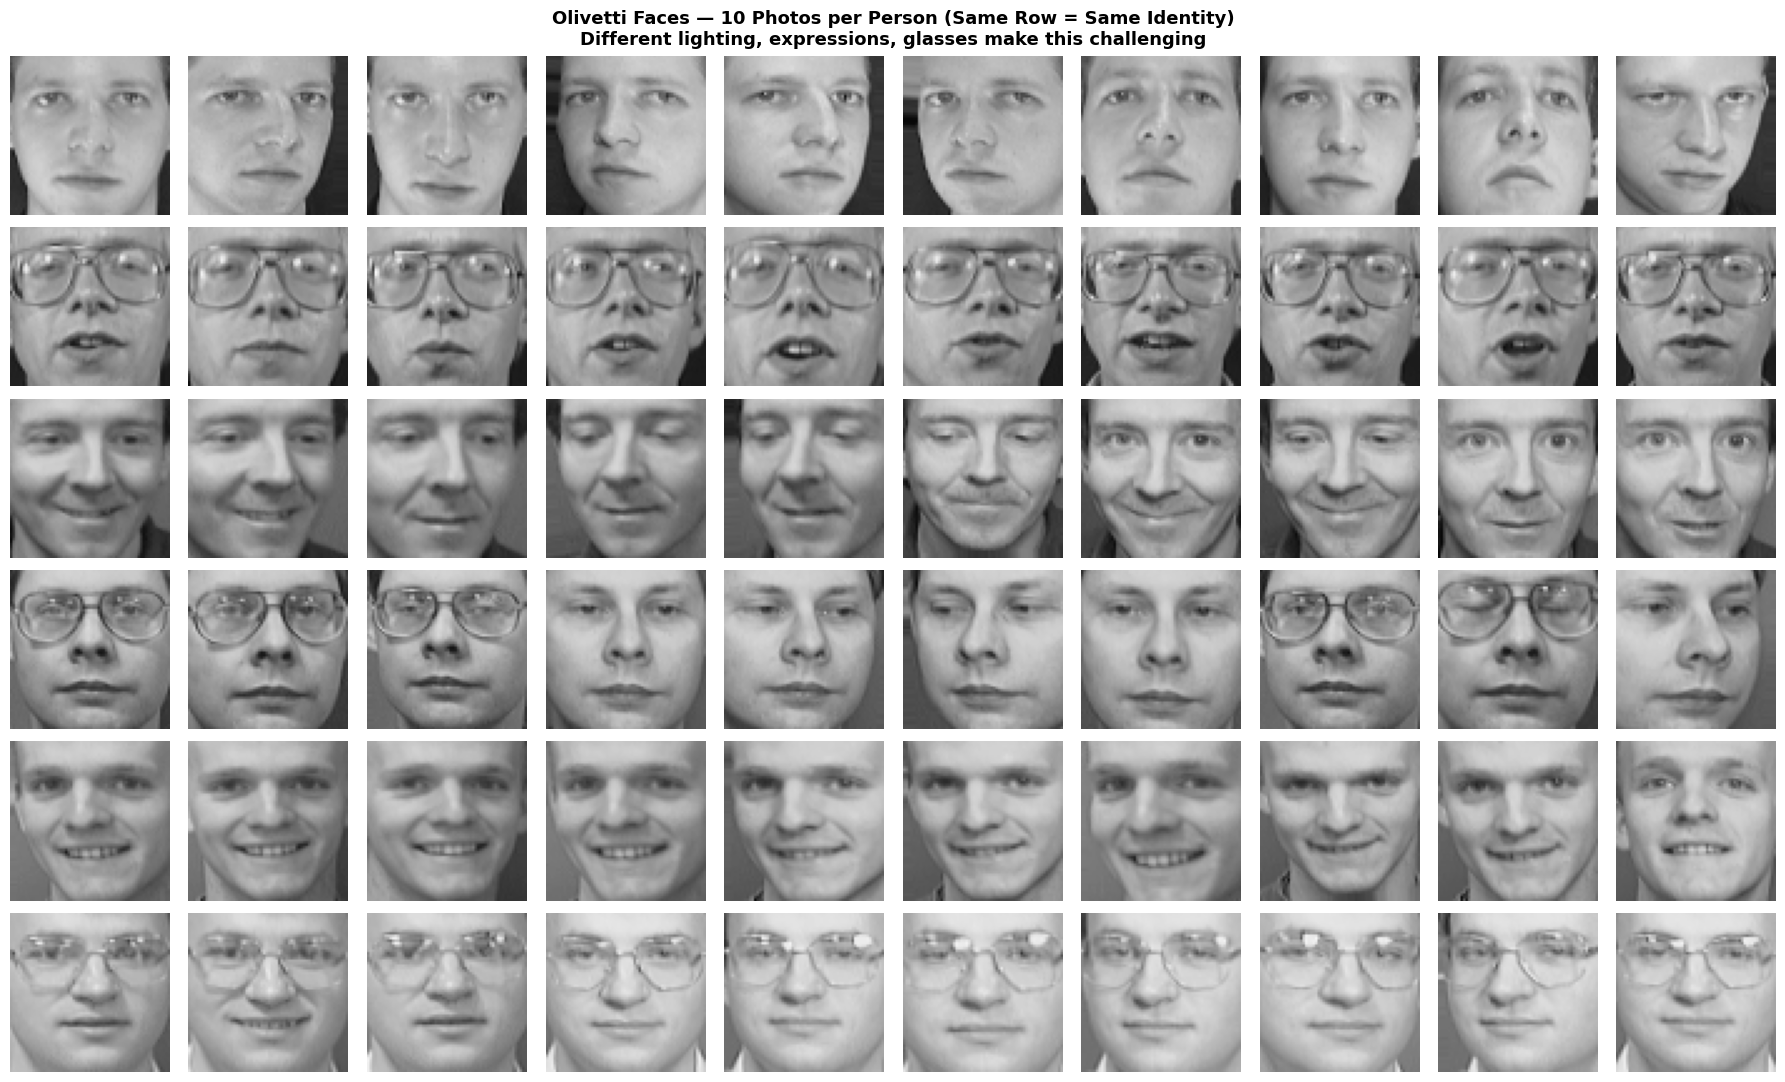

Images are uint8 [0-255] - no black image issues possible


In [4]:
# Show 10 photos of each of the first 6 people
N_SHOW = 6
fig, axes = plt.subplots(N_SHOW, 10, figsize=(18, 11))
fig.suptitle(
    'Olivetti Faces — 10 Photos per Person (Same Row = Same Identity)\n'
    'Different lighting, expressions, glasses make this challenging',
    fontsize=13, fontweight='bold'
)

for row in range(N_SHOW):
    person_id   = row
    person_imgs = images[labels == person_id]  # uint8 [0-255]: correct for imshow
    for col in range(10):
        axes[row, col].imshow(person_imgs[col], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(
        f'Person {person_id+1}', fontsize=10,
        rotation=0, labelpad=55, va='center'
    )

plt.tight_layout()
plt.savefig('olivetti_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Images are uint8 [0-255] - no black image issues possible')


### Show the challenge: same person looks different

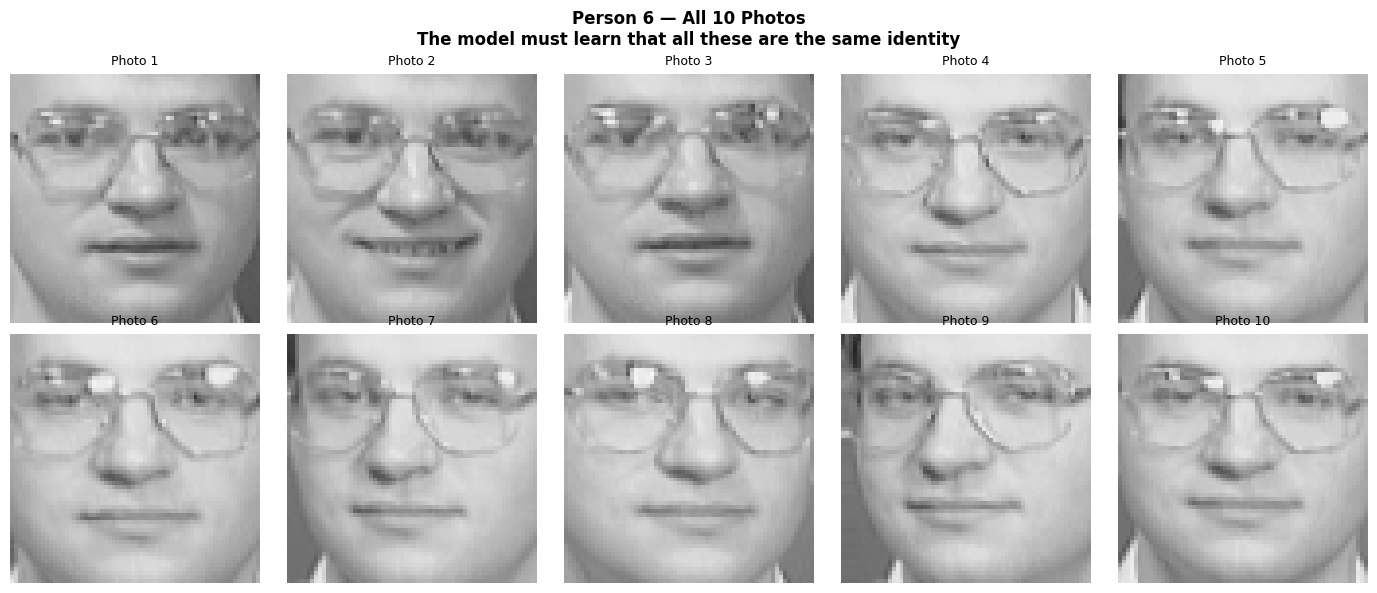

In [5]:
# Pick one person and show how different their 10 photos look
person_id = 5
person_imgs = images[labels == person_id]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(
    f'Person {person_id+1} — All 10 Photos\n'
    'The model must learn that all these are the same identity',
    fontsize=12, fontweight='bold'
)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(person_imgs[idx], cmap='gray')  # uint8: correct
    ax.set_title(f'Photo {idx+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('within_person_variation.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 3 - Load Pre-trained FaceNet

We use **InceptionResnetV1** pre-trained on VGGFace2 (3.3 million face images).
It already knows how to detect and encode faces — we just fine-tune the last
few layers on our dataset.

**Image requirements for FaceNet:**
- Exactly 160x160 pixels
- 3 channels (RGB)
- Normalised to mean=0.5, std=0.5 (range [-1, 1])

We keep this pipeline strictly separate from the display pipeline
(uint8 for display, normalised float for model input).


In [6]:
IMG_SIZE = 160  # FaceNet requires 160x160

# Transform for MODEL INPUT only - NOT for display
model_transform = T.Compose([
    T.ToPILImage(),                              # uint8 array -> PIL Image
    T.Resize((IMG_SIZE, IMG_SIZE)),              # 64x64 -> 160x160
    T.ToTensor(),                                # [0,255] -> [0.0,1.0]
    T.Normalize(mean=[0.5,0.5,0.5],             # [0,1] -> [-1,1]
                std =[0.5,0.5,0.5])
])

# For DISPLAY only - scale uint8 [0,255] image back to float [0,1]
def display_img(uint8_img):
    """Always call this before imshow() to guarantee correct colours."""
    return uint8_img.astype(np.float32) / 255.0

# For model input - returns a tensor in [-1, 1]
def img_to_tensor(uint8_img):
    """Convert uint8 [0-255] RGB image to model-ready tensor [-1,1]."""
    return model_transform(uint8_img)


# Load pre-trained FaceNet
facenet = InceptionResnetV1(pretrained='vggface2', classify=False).to(DEVICE)
facenet.eval()

n_params = sum(p.numel() for p in facenet.parameters())
print(f'FaceNet loaded!')
print(f'Parameters   : {n_params:,}')
print(f'Output dim   : 512 (embedding size)')

# Quick test - one image forward pass
test_t = img_to_tensor(images[0]).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    test_emb = facenet(test_t)
print(f'Test embedding shape: {test_emb.shape}  <- (1, 512)')
print(f'Test embedding norm : {test_emb.norm().item():.4f}')


  0%|          | 0.00/107M [00:00<?, ?B/s]

FaceNet loaded!
Parameters   : 27,910,327
Output dim   : 512 (embedding size)
Test embedding shape: torch.Size([1, 512])  <- (1, 512)
Test embedding norm : 1.0000


## Step 4 - Extract Face Embeddings for All Images

We run every image through FaceNet once and store the 512-D embeddings.
This is much faster than re-running the CNN during the training loop.


In [7]:
BATCH = 32
all_embs = []

print(f'Extracting embeddings for {len(images)} images...')
facenet.eval()

with torch.no_grad():
    for start in range(0, len(images), BATCH):
        batch_imgs = images[start:start+BATCH]  # uint8 [0-255]
        batch_t    = torch.stack([
            img_to_tensor(img) for img in batch_imgs
        ]).to(DEVICE)                           # float [-1,1]

        emb = facenet(batch_t)
        # L2 normalise: all embeddings become unit vectors
        # This makes Euclidean distance = cosine similarity
        emb = nn.functional.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu().numpy())

embeddings = np.vstack(all_embs)  # (400, 512)
print(f'Done! Shape: {embeddings.shape}')
print(f'Embedding range: [{embeddings.min():.3f}, {embeddings.max():.3f}]')
print(f'All unit vectors: {np.allclose(np.linalg.norm(embeddings,axis=1), 1.0, atol=1e-5)}')


Extracting embeddings for 400 images...
Done! Shape: (400, 512)
Embedding range: [-0.164, 0.180]
All unit vectors: True


## Step 5 - Train / Validation Split

We split by **person** (not by image) so validation contains people
the model has never seen during training.

- 32 people (320 images) -> training
- 8 people (80 images) -> validation


In [8]:
all_people    = np.unique(labels)
rng           = np.random.RandomState(SEED)
shuffled      = rng.permutation(all_people)

train_people  = set(shuffled[:32])   # 32 people for training
val_people_set= set(shuffled[32:])   # 8 people for validation

train_mask = np.array([l in train_people  for l in labels])
val_mask   = np.array([l in val_people_set for l in labels])

train_imgs = images[train_mask];     train_lbls = labels[train_mask]
val_imgs   = images[val_mask];       val_lbls   = labels[val_mask]
train_embs = embeddings[train_mask]; val_embs   = embeddings[val_mask]

print(f'Train : {len(train_people)} people, {len(train_imgs)} images')
print(f'Val   : {len(val_people_set)} people, {len(val_imgs)} images')
print(f'No overlap: {len(train_people & val_people_set) == 0}')


Train : 32 people, 320 images
Val   : 8 people, 80 images
No overlap: True


## Step 6 - Build Triplet Dataset

Each sample = (Anchor, Positive, Negative) where:
- Anchor + Positive = same person
- Negative = different person


In [9]:
class TripletDataset(Dataset):
    """
    Generates face triplets for triplet loss training.
    Each item = (anchor_tensor, positive_tensor, negative_tensor)
    All tensors are float [-1,1] ready for FaceNet.
    """
    def __init__(self, imgs, lbls, transform, n_triplets=5000):
        self.imgs      = imgs        # uint8 [0-255]
        self.transform = transform

        # Group indices by person
        id2idx = defaultdict(list)
        for i, l in enumerate(lbls):
            id2idx[l].append(i)

        valid = [k for k,v in id2idx.items() if len(v) >= 2]
        all_k = list(id2idx.keys())

        self.triplets = []
        for _ in range(n_triplets):
            a_id     = random.choice(valid)
            a_i, p_i = random.sample(id2idx[a_id], 2)  # two photos of same person
            n_id     = random.choice([k for k in all_k if k != a_id])
            n_i      = random.choice(id2idx[n_id])      # photo of different person
            self.triplets.append((a_i, p_i, n_i))

        print(f'  Generated {len(self.triplets):,} triplets')

    def __len__(self): return len(self.triplets)

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        # transform converts uint8 [0-255] -> float tensor [-1,1]
        return (self.transform(self.imgs[a]),
                self.transform(self.imgs[p]),
                self.transform(self.imgs[n]))


print('Building triplet datasets...')
train_ds = TripletDataset(train_imgs, train_lbls, model_transform, n_triplets=6000)
val_ds   = TripletDataset(val_imgs,   val_lbls,   model_transform, n_triplets=1000)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_dl)}')
print(f'Val batches   : {len(val_dl)}')


Building triplet datasets...
  Generated 6,000 triplets
  Generated 1,000 triplets
Train batches : 188
Val batches   : 32


## Step 7 - Triplet Loss

```
Loss = mean( max(0,  dist(anchor, positive) - dist(anchor, negative) + margin) )
```

If dist(A,P) + margin < dist(A,N) already -> loss = 0, no update needed.
Otherwise -> gradient pushes A closer to P and further from N.


In [10]:
class TripletLoss(nn.Module):
    """Triplet Margin Loss. margin=0.3 means same-person pairs must be
    at least 0.3 closer than different-person pairs."""
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, a, p, n):
        d_pos = (a - p).pow(2).sum(dim=1)  # dist^2 to positive (same person)
        d_neg = (a - n).pow(2).sum(dim=1)  # dist^2 to negative (diff person)
        return torch.clamp(d_pos - d_neg + self.margin, min=0.0).mean()


criterion = TripletLoss(margin=0.3)
print('TripletLoss ready')
print('Margin = 0.3  (same-person pairs must be 0.3 closer than different-person pairs)')


TripletLoss ready
Margin = 0.3  (same-person pairs must be 0.3 closer than different-person pairs)


## Step 8 - Fine-Tune FaceNet

We freeze most layers and only unfreeze the last inception block.
Olivetti is small (320 training images) so training everything would overfit badly.


In [11]:
# Freeze everything
for p in facenet.parameters():
    p.requires_grad = False

# Unfreeze only last block and final layers
UNFREEZE = ['block8', 'avgpool_1a', 'dropout', 'last_linear', 'last_bn']
for name, p in facenet.named_parameters():
    if any(k in name for k in UNFREEZE):
        p.requires_grad = True

trainable = sum(p.numel() for p in facenet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in facenet.parameters())
print(f'Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)')

optimizer = optim.Adam(
    [p for p in facenet.parameters() if p.requires_grad],
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


Trainable: 2,519,296 / 27,910,327  (9.0%)


In [12]:
EPOCHS = 10
train_losses, val_losses = [], []

print(f'Fine-tuning for {EPOCHS} epochs on {DEVICE}...')
print(f'  {"Ep":>3}  {"Train":>9}  {"Val":>9}  {"Time":>7}')
print('  ' + '-'*33)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    # --- Training ---
    facenet.train()
    tr = []
    for a, p, n in train_dl:
        a, p, n = a.to(DEVICE), p.to(DEVICE), n.to(DEVICE)
        ea = nn.functional.normalize(facenet(a), p=2, dim=1)
        ep = nn.functional.normalize(facenet(p), p=2, dim=1)
        en = nn.functional.normalize(facenet(n), p=2, dim=1)
        loss = criterion(ea, ep, en)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tr.append(loss.item())

    # --- Validation ---
    facenet.eval()
    vl = []
    with torch.no_grad():
        for a, p, n in val_dl:
            ea = nn.functional.normalize(facenet(a.to(DEVICE)), p=2, dim=1)
            ep = nn.functional.normalize(facenet(p.to(DEVICE)), p=2, dim=1)
            en = nn.functional.normalize(facenet(n.to(DEVICE)), p=2, dim=1)
            vl.append(criterion(ea, ep, en).item())

    scheduler.step()
    avg_tr, avg_vl = np.mean(tr), np.mean(vl)
    train_losses.append(avg_tr); val_losses.append(avg_vl)
    print(f'  {epoch:>3}  {avg_tr:>9.4f}  {avg_vl:>9.4f}  {time.time()-t0:>5.1f}s')

print('Fine-tuning complete!')


Fine-tuning for 10 epochs on cuda...
   Ep      Train        Val     Time
  ---------------------------------
    1     0.0023     0.0089   35.3s
    2     0.0001     0.0079   36.6s
    3     0.0002     0.0062   34.9s
    4     0.0001     0.0088   34.0s
    5     0.0000     0.0086   34.8s
    6     0.0002     0.0081   35.3s
    7     0.0000     0.0080   34.4s
    8     0.0000     0.0078   35.6s
    9     0.0000     0.0076   35.5s
   10     0.0001     0.0073   34.9s
Fine-tuning complete!


### Training Loss Curve

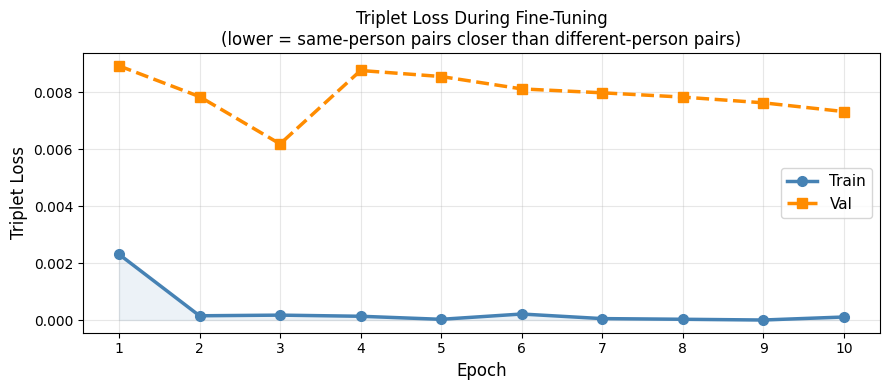

Loss: 0.0023 -> 0.0001  (95.4% reduction)


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ep = range(1, len(train_losses)+1)
ax.plot(ep, train_losses, 'o-', color='steelblue',  lw=2.5, ms=7, label='Train')
ax.plot(ep, val_losses,   's--',color='darkorange', lw=2.5, ms=7, label='Val')
ax.fill_between(ep, train_losses, alpha=0.1, color='steelblue')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Triplet Loss', fontsize=12)
ax.set_title('Triplet Loss During Fine-Tuning\n'
             '(lower = same-person pairs closer than different-person pairs)',
             fontsize=12)
ax.legend(fontsize=11); ax.grid(alpha=0.3); ax.set_xticks(list(ep))
plt.tight_layout()
plt.savefig('triplet_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Loss: {train_losses[0]:.4f} -> {train_losses[-1]:.4f}  '
      f'({(1-train_losses[-1]/train_losses[0])*100:.1f}% reduction)')


## Step 9 - Re-extract Embeddings After Fine-Tuning

In [14]:
print('Re-extracting embeddings with fine-tuned model...')
facenet.eval()
ft_list = []

with torch.no_grad():
    for start in range(0, len(images), BATCH):
        batch_t = torch.stack([
            img_to_tensor(img) for img in images[start:start+BATCH]
        ]).to(DEVICE)
        emb = nn.functional.normalize(facenet(batch_t), p=2, dim=1)
        ft_list.append(emb.cpu().numpy())

embeddings_ft = np.vstack(ft_list)       # (400, 512)
val_embs_ft   = embeddings_ft[val_mask]
print(f'Done! Shape: {embeddings_ft.shape}')

# Measure separation improvement
def sep_ratio(embs, lbls, n=300):
    idx  = np.random.choice(len(embs), min(n, len(embs)), replace=False)
    same, diff = [], []
    for i in range(len(idx)):
        for j in range(i+1, len(idx)):
            d = np.linalg.norm(embs[idx[i]] - embs[idx[j]])
            (same if lbls[idx[i]]==lbls[idx[j]] else diff).append(d)
    ms = np.mean(same) if same else 0
    md = np.mean(diff) if diff else 1
    return ms, md, md/ms if ms > 0 else 0

s0,d0,r0 = sep_ratio(embeddings,    labels)
s1,d1,r1 = sep_ratio(embeddings_ft, labels)

print(f'\n{"":<35} {"Before":>10} {"After":>10}')
print('-'*57)
print(f'{"Avg same-person distance":<35} {s0:>10.4f} {s1:>10.4f}')
print(f'{"Avg diff-person distance":<35} {d0:>10.4f} {d1:>10.4f}')
print(f'{"Separation ratio (higher=better)":<35} {r0:>10.4f} {r1:>10.4f}')


Re-extracting embeddings with fine-tuned model...
Done! Shape: (400, 512)

                                        Before      After
---------------------------------------------------------
Avg same-person distance                0.5291     0.6211
Avg diff-person distance                1.3329     1.4175
Separation ratio (higher=better)        2.5193     2.2821


## Step 10 - Face Verification: Calibrate Distance Threshold

The threshold decides: distance < threshold = same person.

We find the best threshold using the **Equal Error Rate (EER)** —
the point where false accepts = false rejects.


In [15]:
id_to_vi = defaultdict(list)
for i, l in enumerate(val_lbls):
    id_to_vi[l].append(i)
val_people_list = [p for p,idxs in id_to_vi.items() if len(idxs) >= 2]

e1_l, e2_l, yt_l = [], [], []
N_PAIRS = 500  # enough for 40 val images

for _ in range(N_PAIRS // 2):
    # Positive pair - same person
    pid  = random.choice(val_people_list)
    i, j = random.sample(id_to_vi[pid], 2)
    e1_l.append(val_embs_ft[i]); e2_l.append(val_embs_ft[j]); yt_l.append(1)

    # Negative pair - different people
    p1, p2 = random.sample(val_people_list, 2)
    i = random.choice(id_to_vi[p1])
    j = random.choice(id_to_vi[p2])
    e1_l.append(val_embs_ft[i]); e2_l.append(val_embs_ft[j]); yt_l.append(0)

e1, e2   = np.array(e1_l), np.array(e2_l)
y_true   = np.array(yt_l)
dists    = np.linalg.norm(e1 - e2, axis=1)

# ROC curve
fpr, tpr, thresh = roc_curve(y_true, -dists)  # negate: smaller dist = more positive
roc_auc = auc(fpr, tpr)

# EER threshold
fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer_thr = -thresh[eer_idx]
eer_val = (fpr[eer_idx] + fnr[eer_idx]) / 2

# Best accuracy threshold
tr_range = np.linspace(dists.min(), dists.max(), 150)
accs     = [accuracy_score(y_true, (dists <= t).astype(int)) for t in tr_range]
best_acc = max(accs)
best_thr = tr_range[int(np.argmax(accs))]

print(f'ROC AUC          : {roc_auc:.4f}')
print(f'EER              : {eer_val*100:.2f}%  (threshold={eer_thr:.4f})')
print(f'Best Accuracy    : {best_acc*100:.2f}%  (threshold={best_thr:.4f})')


ROC AUC          : 0.9945
EER              : 3.20%  (threshold=1.1647)
Best Accuracy    : 96.80%  (threshold=1.1649)


### Visualise Verification Performance

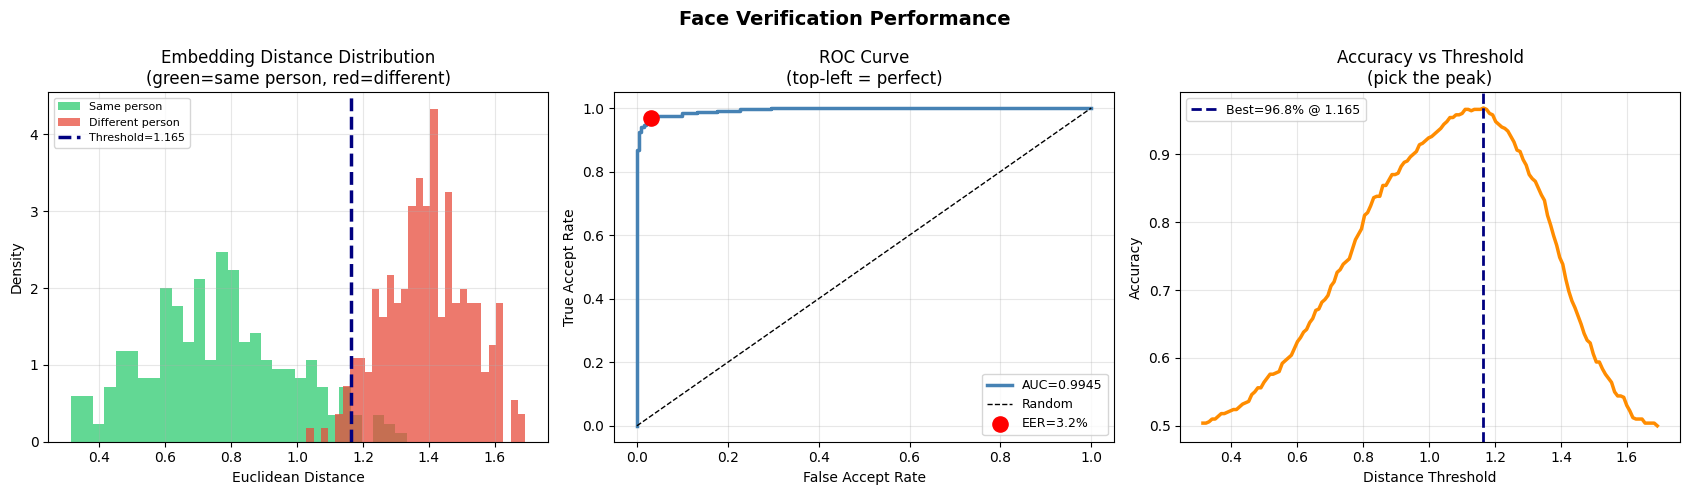

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Face Verification Performance', fontsize=14, fontweight='bold')

# Distance distributions
axes[0].hist(dists[y_true==1], bins=30, alpha=0.75, color='#2ecc71',
             label='Same person', density=True)
axes[0].hist(dists[y_true==0], bins=30, alpha=0.75, color='#e74c3c',
             label='Different person', density=True)
axes[0].axvline(best_thr, color='navy', ls='--', lw=2.5,
                label=f'Threshold={best_thr:.3f}')
axes[0].set_xlabel('Euclidean Distance'); axes[0].set_ylabel('Density')
axes[0].set_title('Embedding Distance Distribution\n'
                  '(green=same person, red=different)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# ROC
axes[1].plot(fpr, tpr, color='steelblue', lw=2.5, label=f'AUC={roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[1].scatter(fpr[eer_idx],tpr[eer_idx],s=120,color='red',zorder=5,
                label=f'EER={eer_val*100:.1f}%')
axes[1].set_xlabel('False Accept Rate'); axes[1].set_ylabel('True Accept Rate')
axes[1].set_title('ROC Curve\n(top-left = perfect)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Accuracy vs threshold
axes[2].plot(tr_range, accs, color='darkorange', lw=2.5)
axes[2].axvline(best_thr, color='navy', ls='--', lw=2,
                label=f'Best={best_acc*100:.1f}% @ {best_thr:.3f}')
axes[2].set_xlabel('Distance Threshold'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy vs Threshold\n(pick the peak)')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('verification_performance.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 11 - t-SNE: Visualise the 512-D Embedding Space

t-SNE compresses 512 dimensions to 2D while preserving local structure.
**Tight separate clusters = the model has learned good face representations.**


t-SNE on 400 images (40 people)...
Done!


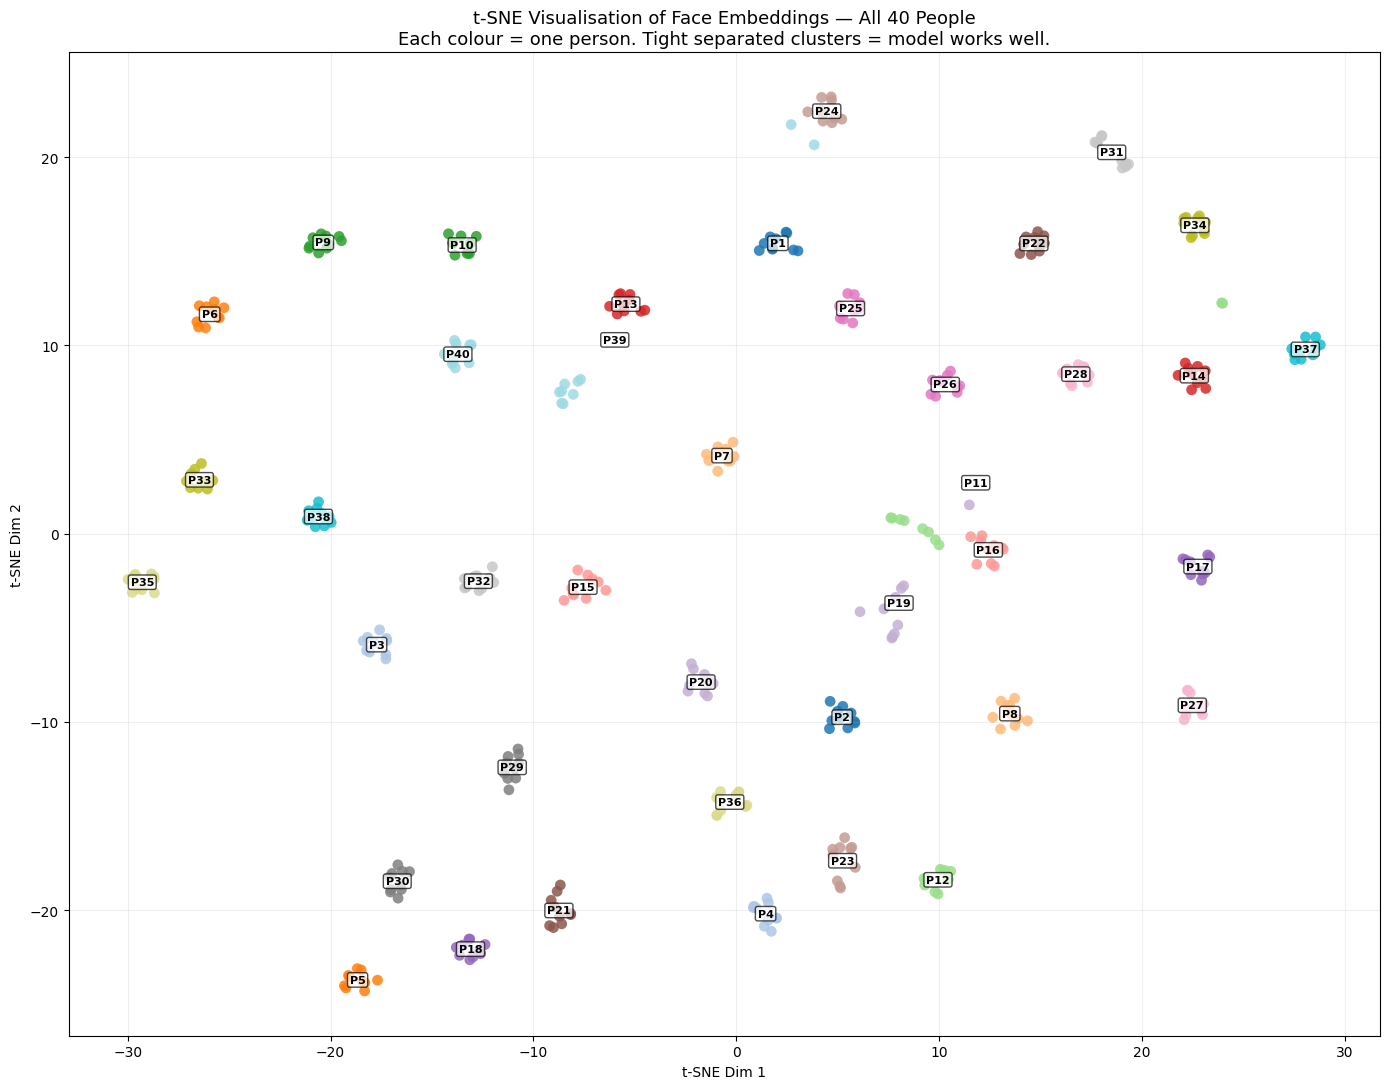

In [17]:
# Use all 40 people for t-SNE (400 images total)
print(f't-SNE on {len(embeddings_ft)} images ({len(np.unique(labels))} people)...')
tsne  = TSNE(n_components=2, perplexity=20, random_state=SEED, n_iter=1500, verbose=0)
emb2d = tsne.fit_transform(embeddings_ft)
print('Done!')

# Assign unique colour to each person
unique_people = np.unique(labels)
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_people)))
id2col  = {pid: palette[i] for i, pid in enumerate(unique_people)}

fig, ax = plt.subplots(figsize=(14, 11))

for pid in unique_people:
    mask = labels == pid
    pts  = emb2d[mask]
    ax.scatter(pts[:,0], pts[:,1], c=[id2col[pid]], s=60,
               alpha=0.85, edgecolors='none')
    # Label each cluster
    cen = pts.mean(axis=0)
    ax.annotate(
        f'P{pid+1}', cen,
        fontsize=8, fontweight='bold', ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2')
    )

ax.set_title(
    't-SNE Visualisation of Face Embeddings — All 40 People\n'
    'Each colour = one person. Tight separated clusters = model works well.',
    fontsize=13
)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=130, bbox_inches='tight')
plt.show()


## Step 12 - Face Identification Demo (1-to-N Gallery Search)

Enrol one photo per person in a gallery. Query with a different photo.
Find the closest gallery match. If distance < threshold -> identified.


In [18]:
# Build gallery: use photo index 0 per person
all_people_list = list(np.unique(labels))
gal_embs = {}
gal_imgs = {}

for pid in all_people_list:
    idx = np.where(labels == pid)[0][0]      # first photo -> gallery
    gal_embs[pid] = embeddings_ft[idx]
    gal_imgs[pid] = images[idx]              # uint8 [0-255]

print(f'Gallery: {len(gal_embs)} enrolled people')

# Query: use photo index 5 per person (different from gallery entry)
rows = []
for pid in all_people_list:
    pid_idxs = np.where(labels == pid)[0]
    q_idx    = pid_idxs[5]                   # 6th photo -> query
    q_emb    = embeddings_ft[q_idx]

    dists_g  = {gid: float(np.linalg.norm(q_emb - ge))
                for gid, ge in gal_embs.items()}
    pred_id  = min(dists_g, key=dists_g.get)
    min_d    = dists_g[pred_id]

    rows.append({
        'True ID'  : f'Person {pid+1}',
        'Predicted': f'Person {pred_id+1}',
        'Distance' : round(min_d, 4),
        'Accept?'  : 'Yes' if min_d < best_thr else 'No',
        'Result'   : 'CORRECT' if pred_id == pid else 'WRONG',
    })

import pandas as pd
results_df = pd.DataFrame(rows)
n_ok = sum(1 for r in rows if r['Result']=='CORRECT')
print(f'Identification Accuracy: {n_ok}/{len(rows)} = {n_ok/len(rows)*100:.1f}%')
print()
print('First 15 results:')
display(results_df.head(15))


Gallery: 40 enrolled people
Identification Accuracy: 38/40 = 95.0%

First 15 results:


,True ID,Predicted,Distance,Accept?,Result
0,Person 1,Person 1,0.5684,Yes,CORRECT
1,Person 2,Person 2,0.7132,Yes,CORRECT
2,Person 3,Person 3,0.5637,Yes,CORRECT
3,Person 4,Person 4,0.6520,Yes,CORRECT
4,Person 5,Person 5,0.4041,Yes,CORRECT
5,Person 6,Person 6,0.8075,Yes,CORRECT
6,Person 7,Person 7,0.6916,Yes,CORRECT
7,Person 8,Person 8,0.5859,Yes,CORRECT
8,Person 9,Person 9,0.5236,Yes,CORRECT
9,Person 10,Person 10,0.5563,Yes,CORRECT


### Visual: Query vs Top-3 Gallery Matches

All images are stored as uint8 [0-255] and displayed with `cmap='gray'`.
No normalisation issues — no black images.


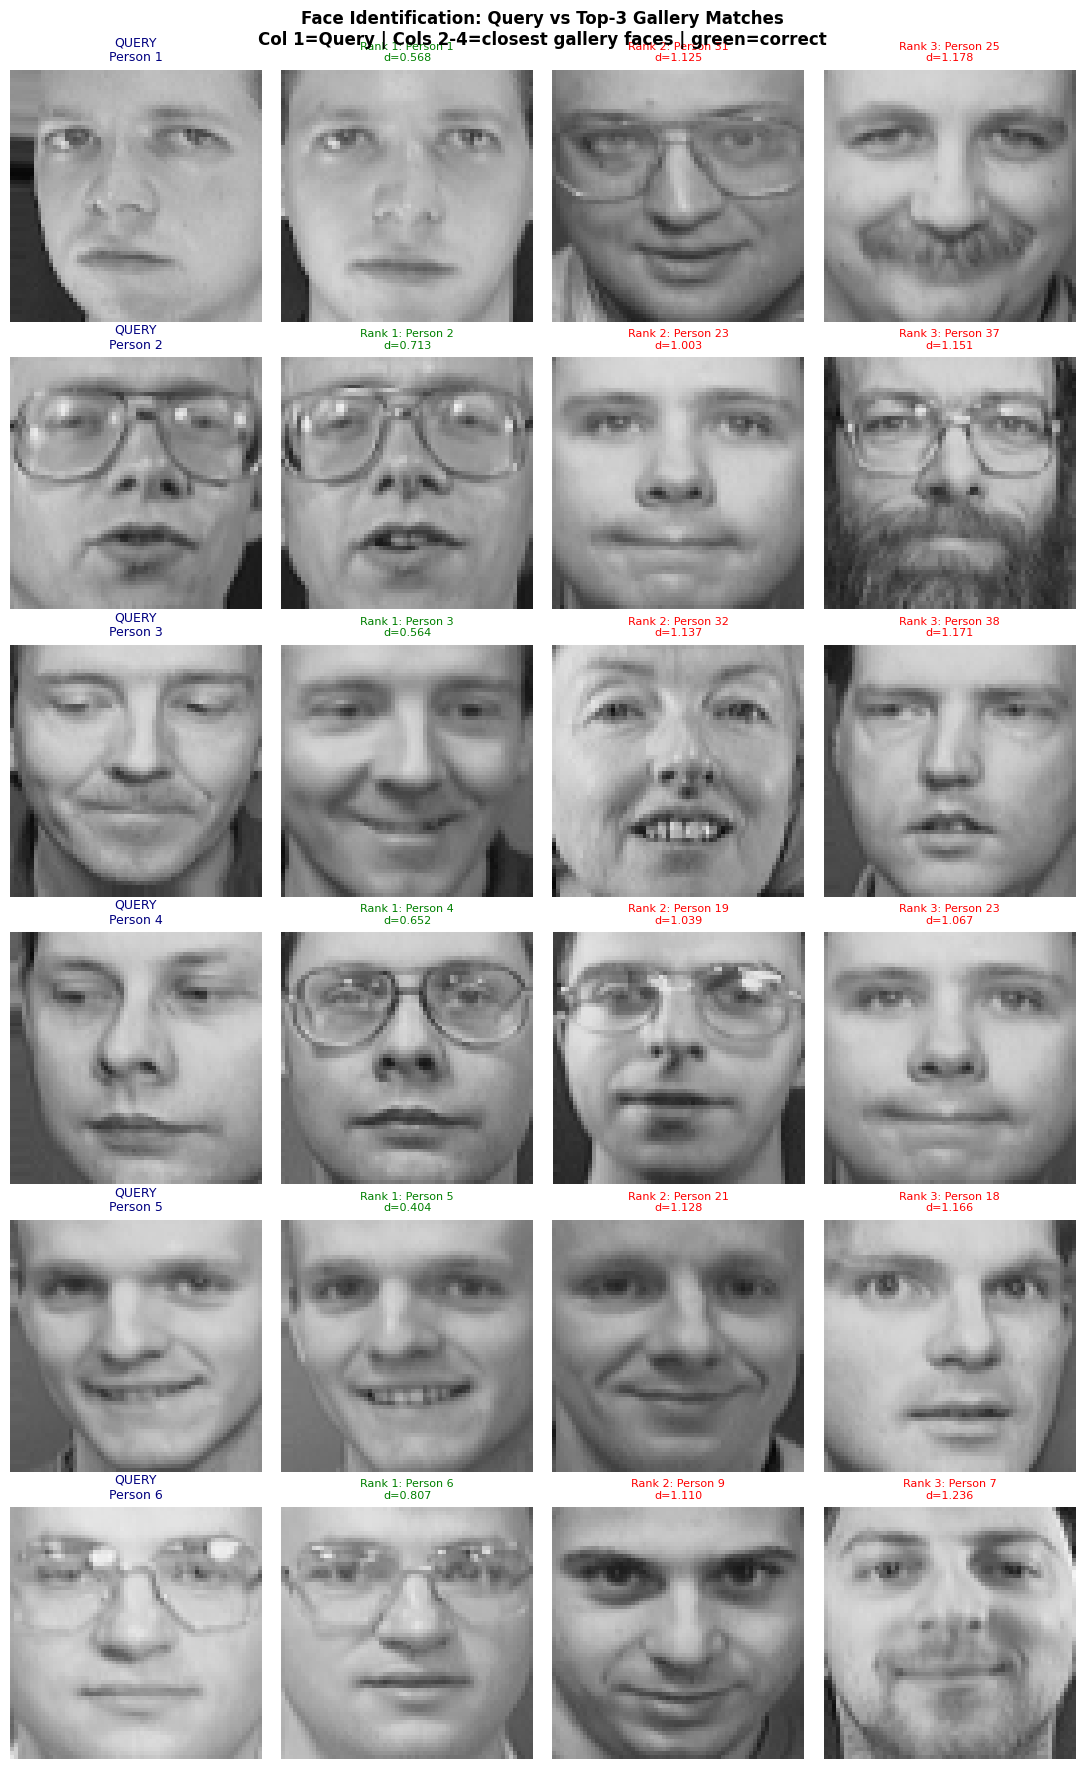

Green=correct | Red=wrong


In [19]:
SHOW_N = 6
show_people = all_people_list[:SHOW_N]

fig, axes = plt.subplots(SHOW_N, 4, figsize=(11, 3*SHOW_N))
fig.suptitle(
    'Face Identification: Query vs Top-3 Gallery Matches\n'
    'Col 1=Query | Cols 2-4=closest gallery faces | green=correct',
    fontsize=12, fontweight='bold'
)

for row, pid in enumerate(show_people):
    pid_idxs = np.where(labels == pid)[0]
    q_idx    = pid_idxs[5]         # 6th photo as query
    q_emb    = embeddings_ft[q_idx]

    # Sort gallery by distance
    sorted_g = sorted(
        {gid: float(np.linalg.norm(q_emb - ge))
         for gid, ge in gal_embs.items()}.items(),
        key=lambda x: x[1]
    )

    # Column 0: query image
    # display_img() converts uint8->float [0,1] for imshow (no black images)
    axes[row,0].imshow(display_img(images[q_idx]), cmap='gray')
    axes[row,0].set_title(f'QUERY\nPerson {pid+1}', fontsize=9, color='navy')
    axes[row,0].axis('off')

    # Columns 1-3: closest gallery matches
    for col, (mid, d) in enumerate(sorted_g[:3], start=1):
        axes[row,col].imshow(display_img(gal_imgs[mid]), cmap='gray')
        is_match = (mid == pid)
        axes[row,col].set_title(
            f'Rank {col}: Person {mid+1}\nd={d:.3f}',
            fontsize=8, color='green' if is_match else 'red'
        )
        axes[row,col].axis('off')

plt.tight_layout()
plt.savefig('face_identification.png', dpi=100, bbox_inches='tight')
plt.show()
print('Green=correct | Red=wrong')


## Step 13 - Visual Pair Verification

Show actual same-person pairs and different-person pairs with their distances.
This makes it concrete what 'distance < threshold' means visually.


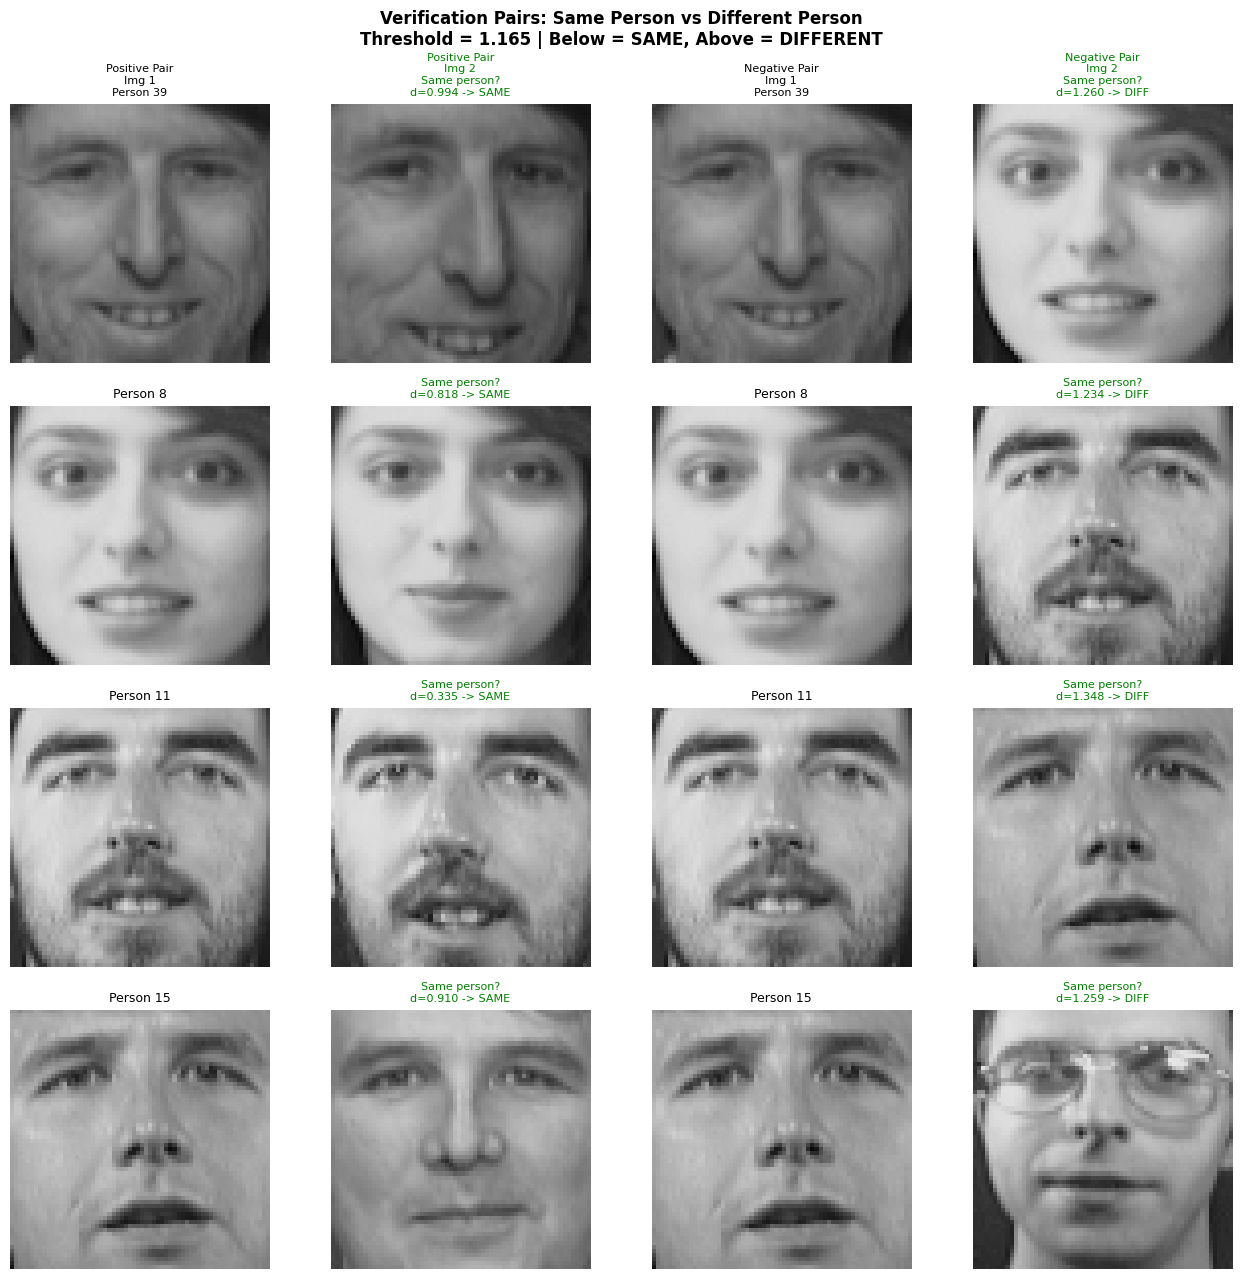

In [20]:
val_people_list2 = list(val_people_set)
id_to_vi2 = defaultdict(list)
for i, l in enumerate(val_lbls):
    id_to_vi2[l].append(i)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
fig.suptitle(
    'Verification Pairs: Same Person vs Different Person\n'
    f'Threshold = {best_thr:.3f} | Below = SAME, Above = DIFFERENT',
    fontsize=12, fontweight='bold'
)

pair_idx = 0

# 8 positive pairs (top 8 subplots, 2 images each)
for row in range(4):
    pid  = val_people_list2[row % len(val_people_list2)]
    idxs = id_to_vi2[pid]
    if len(idxs) < 2:
        continue
    i, j = idxs[0], idxs[1]
    d = np.linalg.norm(val_embs_ft[i] - val_embs_ft[j])
    decision = 'SAME' if d < best_thr else 'DIFF'
    correct  = decision == 'SAME'

    # Left image
    axes[row,0].imshow(display_img(val_imgs[i]), cmap='gray')
    axes[row,0].set_title(f'Person {pid+1}', fontsize=9)
    axes[row,0].axis('off')

    # Right image + distance + decision
    axes[row,1].imshow(display_img(val_imgs[j]), cmap='gray')
    axes[row,1].set_title(
        f'Same person?\nd={d:.3f} -> {decision}',
        fontsize=8, color='green' if correct else 'red'
    )
    axes[row,1].axis('off')

    # Negative pair
    other = [p for p in val_people_list2 if p != pid]
    if not other: continue
    neg_id = other[row % len(other)]
    ni     = id_to_vi2[neg_id][0]
    d2 = np.linalg.norm(val_embs_ft[i] - val_embs_ft[ni])
    decision2 = 'SAME' if d2 < best_thr else 'DIFF'
    correct2  = decision2 == 'DIFF'

    axes[row,2].imshow(display_img(val_imgs[i]), cmap='gray')
    axes[row,2].set_title(f'Person {pid+1}', fontsize=9)
    axes[row,2].axis('off')

    axes[row,3].imshow(display_img(val_imgs[ni]), cmap='gray')
    axes[row,3].set_title(
        f'Same person?\nd={d2:.3f} -> {decision2}',
        fontsize=8, color='green' if correct2 else 'red'
    )
    axes[row,3].axis('off')

# Column labels
for ax, title in zip(axes[0], ['Positive Pair\nImg 1','Positive Pair\nImg 2',
                                'Negative Pair\nImg 1','Negative Pair\nImg 2']):
    ax.set_title(title + '\n' + ax.get_title(), fontsize=8)

plt.tight_layout()
plt.savefig('verification_pairs.png', dpi=100, bbox_inches='tight')
plt.show()


## Summary

In [21]:
print('=' * 62)
print('  FACE RECOGNITION - EXPERIMENT SUMMARY')
print('=' * 62)
print(f'  Dataset          : Olivetti Faces (400 images, 40 people)')
print(f'  Model            : InceptionResnetV1 (VGGFace2 pre-trained)')
print(f'  Embedding size   : 512-D (L2 normalised)')
print(f'  Loss             : Triplet Loss (margin=0.3)')
print(f'  Fine-tune epochs : {EPOCHS}')
print()
print(f'  Verification AUC        : {roc_auc:.4f}')
print(f'  Best Verification Acc   : {best_acc*100:.2f}%  @ threshold={best_thr:.4f}')
print(f'  EER                     : {eer_val*100:.2f}%')
print(f'  Identification Accuracy : {n_ok}/{len(rows)} = {n_ok/len(rows)*100:.1f}%')
print(f'  Separation ratio before : {r0:.4f}')
print(f'  Separation ratio after  : {r1:.4f}')
print()
for fname in ['olivetti_samples.png','within_person_variation.png',
              'triplet_loss_curve.png','verification_performance.png',
              'tsne_embeddings.png','face_identification.png',
              'verification_pairs.png']:
    print(f'  saved: {fname}')
print('=' * 62)


  FACE RECOGNITION - EXPERIMENT SUMMARY
  Dataset          : Olivetti Faces (400 images, 40 people)
  Model            : InceptionResnetV1 (VGGFace2 pre-trained)
  Embedding size   : 512-D (L2 normalised)
  Loss             : Triplet Loss (margin=0.3)
  Fine-tune epochs : 10

  Verification AUC        : 0.9945
  Best Verification Acc   : 96.80%  @ threshold=1.1649
  EER                     : 3.20%
  Identification Accuracy : 38/40 = 95.0%
  Separation ratio before : 2.5193
  Separation ratio after  : 2.2821

  saved: olivetti_samples.png
  saved: within_person_variation.png
  saved: triplet_loss_curve.png
  saved: verification_performance.png
  saved: tsne_embeddings.png
  saved: face_identification.png
  saved: verification_pairs.png


## Conclusion

| Component | Detail |
|-----------|--------|
| Dataset | Olivetti Faces (40 people, 10 photos each, clean uint8) |
| Model | InceptionResnetV1 pre-trained on VGGFace2 |
| Training | Triplet Loss, last block fine-tuned |
| Display | All images stored as uint8 [0-255], displayed via float [0,1] |
| Verification | EER-calibrated distance threshold |
| Identification | Nearest-neighbour gallery search |

### Key Takeaways

1. **Image pipeline matters** - always store as uint8, always convert to float for display
2. **Triplet loss shapes the space** - same person pulls together, different people push apart
3. **EER gives honest threshold** - balances false accepts vs false rejects
4. **t-SNE reveals quality** - tight separate clusters = good embeddings
5. **Olivetti is ideal for learning** - clean, balanced, no download friction
